In [1]:
import model3_pipeline as m3

In [2]:
df = m3.load_data(
    "cmu_real.csv",
    "vae_synthetic.csv",
    "chatgpt_cmu_synthetic_dataset.csv"
)

Combined shape: (61200, 34)

Class counts:
label
2    20400
0    20400
1    20400
Name: count, dtype: int64


In [3]:
X, y = m3.preprocess_data(df)


Dropping columns: ['subject', 'sessionIndex']

Feature shape: (61200, 31)
Label shape: (61200,)


In [4]:
X_train, X_test, y_train, y_test = m3.split_data(X, y)


Train shape: (48960, 31)
Test shape: (12240, 31)


In [5]:
X_train_mi, X_test_mi, mi_features, mi_scores = m3.select_mutual_info(
    X_train, y_train, X_test, k=10
)
X_train_mi_scaled, X_test_mi_scaled = m3.scale_data(X_train_mi, X_test_mi)
mi_results = m3.evaluate_models(X_train_mi_scaled, X_test_mi_scaled, y_train, y_test)


Top Mutual Information Features:
     Feature     Score
12    H.five  0.527090
30  H.Return  0.504055
0   H.period  0.503841
3        H.t  0.495660
18       H.o  0.489459
6        H.i  0.482517
9        H.e  0.481313
27       H.l  0.480314
24       H.n  0.477172
8     UD.i.e  0.472753

Model: Logistic Regression
Accuracy: 0.4025326797385621

Confusion Matrix:
[[1168 1587 1254]
 [ 899 2395  825]
 [1042 1706 1364]]

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.29      0.33      4009
           1       0.42      0.58      0.49      4119
           2       0.40      0.33      0.36      4112

    accuracy                           0.40     12240
   macro avg       0.40      0.40      0.39     12240
weighted avg       0.40      0.40      0.39     12240


Model: Linear SVM
Accuracy: 0.40318627450980393

Confusion Matrix:
[[1147 1635 1227]
 [ 856 2441  822]
 [1013 1752 1347]]

Classification Report:
              precision    rec

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Accuracy: 0.6757352941176471

Confusion Matrix:
[[2904  858  247]
 [ 992 2561  566]
 [ 509  797 2806]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.72      0.69      4009
           1       0.61      0.62      0.61      4119
           2       0.78      0.68      0.73      4112

    accuracy                           0.68     12240
   macro avg       0.68      0.68      0.68     12240
weighted avg       0.68      0.68      0.68     12240


Model: Naive Bayes
Accuracy: 0.5008169934640523

Confusion Matrix:
[[1558 2232  219]
 [ 826 3049  244]
 [1105 1484 1523]]

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.39      0.42      4009
           1       0.45      0.74      0.56      4119
           2       0.77      0.37      0.50      4112

    accuracy                           0.50     12240
   macro avg       0.55      0.50      0.49     12240
weighted avg       

In [6]:
X_train_anova, X_test_anova, anova_features, anova_scores = m3.select_anova(
    X_train, y_train, X_test, k=10
)
X_train_anova_scaled, X_test_anova_scaled = m3.scale_data(X_train_anova, X_test_anova)
anova_results = m3.evaluate_models(X_train_anova_scaled, X_test_anova_scaled, y_train, y_test)


Top ANOVA Features:
            Feature       Score        P_Value
10        DD.e.five  388.607896  3.592343e-168
11        UD.e.five  299.832745  3.761273e-130
21              H.a  284.226995  1.874665e-123
14  UD.five.Shift.r  212.610634   1.156282e-92
30         H.Return  192.279397   6.612750e-84
8            UD.i.e  177.908458   1.034578e-77
16     DD.Shift.r.o  153.420377   3.787135e-67
7            DD.i.e  138.393471   1.163442e-60
15        H.Shift.r   85.204560   1.149164e-37
9               H.e   82.245190   2.194012e-36

Model: Logistic Regression
Accuracy: 0.46176470588235297

Confusion Matrix:
[[1368 1551 1090]
 [ 828 2800  491]
 [1241 1387 1484]]

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.34      0.37      4009
           1       0.49      0.68      0.57      4119
           2       0.48      0.36      0.41      4112

    accuracy                           0.46     12240
   macro avg       0.46      0.46 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Accuracy: 0.46176470588235297

Confusion Matrix:
[[1272 1648 1089]
 [ 720 2914  485]
 [1182 1464 1466]]

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.32      0.35      4009
           1       0.48      0.71      0.57      4119
           2       0.48      0.36      0.41      4112

    accuracy                           0.46     12240
   macro avg       0.46      0.46      0.45     12240
weighted avg       0.46      0.46      0.45     12240


Model: Random Forest
Accuracy: 0.7722222222222223

Confusion Matrix:
[[3125  682  202]
 [ 835 2982  302]
 [ 284  483 3345]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.78      0.76      4009
           1       0.72      0.72      0.72      4119
           2       0.87      0.81      0.84      4112

    accuracy                           0.77     12240
   macro avg       0.77      0.77      0.77     12240
weighted avg    

In [7]:
X_train_corr, X_test_corr, corr_features, corr_scores = m3.select_correlation(
    X_train, y_train, X_test, k=10
)
X_train_corr_scaled, X_test_corr_scaled = m3.scale_data(X_train_corr, X_test_corr)
corr_results = m3.evaluate_models(X_train_corr_scaled, X_test_corr_scaled, y_train, y_test)


Top Correlation Features:
           Feature     Score
0  UD.five.Shift.r  0.056219
1        UD.e.five  0.047668
2      UD.l.Return  0.042736
3     UD.Shift.r.o  0.038349
4           UD.n.l  0.034703
5      UD.period.t  0.033567
6           UD.o.a  0.028007
7           UD.t.i  0.025775
8           UD.i.e  0.020741
9           UD.a.n  0.016865

Model: Logistic Regression
Accuracy: 0.39477124183006534

Confusion Matrix:
[[1127 1213 1669]
 [ 763 2389  967]
 [1231 1565 1316]]

Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.28      0.32      4009
           1       0.46      0.58      0.51      4119
           2       0.33      0.32      0.33      4112

    accuracy                           0.39     12240
   macro avg       0.39      0.39      0.39     12240
weighted avg       0.39      0.39      0.39     12240


Model: Linear SVM
Accuracy: 0.3981209150326797

Confusion Matrix:
[[1110 1267 1632]
 [ 743 2464  912]
 [1211 1602 12

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Accuracy: 0.8325163398692811

Confusion Matrix:
[[3231  660  118]
 [ 622 3279  218]
 [  99  333 3680]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      4009
           1       0.77      0.80      0.78      4119
           2       0.92      0.89      0.91      4112

    accuracy                           0.83     12240
   macro avg       0.83      0.83      0.83     12240
weighted avg       0.83      0.83      0.83     12240


Model: Naive Bayes
Accuracy: 0.5245915032679739

Confusion Matrix:
[[ 825 2847  337]
 [ 425 3584  110]
 [1471  629 2012]]

Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.21      0.25      4009
           1       0.51      0.87      0.64      4119
           2       0.82      0.49      0.61      4112

    accuracy                           0.52     12240
   macro avg       0.54      0.52      0.50     12240
weighted avg       

In [8]:
X_train_var, X_test_var, var_features, var_scores = m3.select_variance(
    X_train, X_test, threshold=0.0, k=10
)
X_train_var_scaled, X_test_var_scaled = m3.scale_data(X_train_var, X_test_var)
var_results = m3.evaluate_models(X_train_var_scaled, X_test_var_scaled, y_train, y_test)


Top Variance Features:
           Feature     Score
0  UD.five.Shift.r  0.062063
1        UD.e.five  0.060306
2        DD.e.five  0.054787
3  DD.five.Shift.r  0.053056
4      UD.l.Return  0.046348
5      UD.period.t  0.044140
6      DD.l.Return  0.041274
7      DD.period.t  0.039889
8           UD.i.e  0.029614
9           DD.i.e  0.028532

Model: Logistic Regression
Accuracy: 0.43790849673202614

Confusion Matrix:
[[1335 1636 1038]
 [ 993 2508  618]
 [1237 1358 1517]]

Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.33      0.35      4009
           1       0.46      0.61      0.52      4119
           2       0.48      0.37      0.42      4112

    accuracy                           0.44     12240
   macro avg       0.44      0.44      0.43     12240
weighted avg       0.44      0.44      0.43     12240


Model: Linear SVM


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Accuracy: 0.4372549019607843

Confusion Matrix:
[[1291 1752  966]
 [ 963 2594  562]
 [1237 1408 1467]]

Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.32      0.34      4009
           1       0.45      0.63      0.53      4119
           2       0.49      0.36      0.41      4112

    accuracy                           0.44     12240
   macro avg       0.44      0.44      0.43     12240
weighted avg       0.44      0.44      0.43     12240


Model: Random Forest
Accuracy: 0.7555555555555555

Confusion Matrix:
[[3004  834  171]
 [ 899 2891  329]
 [ 205  554 3353]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.75      0.74      4009
           1       0.68      0.70      0.69      4119
           2       0.87      0.82      0.84      4112

    accuracy                           0.76     12240
   macro avg       0.76      0.76      0.76     12240
weighted avg     

In [9]:
X_train_md, X_test_md, md_features, md_scores = m3.select_mean_difference(
    X_train, y_train, X_test, k=10
)
X_train_md_scaled, X_test_md_scaled = m3.scale_data(X_train_md, X_test_md)
md_results = m3.evaluate_models(X_train_md_scaled, X_test_md_scaled, y_train, y_test)


Top Mean Difference Features:
           Feature     Score
0        UD.e.five  0.131899
1        DD.e.five  0.125390
2  UD.five.Shift.r  0.112444
3           UD.i.e  0.068977
4           DD.i.e  0.054866
5     DD.Shift.r.o  0.051109
6      UD.l.Return  0.045074
7     UD.Shift.r.o  0.042445
8  DD.five.Shift.r  0.037795
9      UD.period.t  0.034550

Model: Logistic Regression
Accuracy: 0.4438725490196078

Confusion Matrix:
[[1277 1556 1176]
 [ 852 2594  673]
 [1187 1363 1562]]

Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.32      0.35      4009
           1       0.47      0.63      0.54      4119
           2       0.46      0.38      0.42      4112

    accuracy                           0.44     12240
   macro avg       0.44      0.44      0.43     12240
weighted avg       0.44      0.44      0.43     12240


Model: Linear SVM


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Accuracy: 0.4452614379084967

Confusion Matrix:
[[1246 1646 1117]
 [ 819 2688  612]
 [1178 1418 1516]]

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.31      0.34      4009
           1       0.47      0.65      0.54      4119
           2       0.47      0.37      0.41      4112

    accuracy                           0.45     12240
   macro avg       0.44      0.44      0.43     12240
weighted avg       0.44      0.45      0.43     12240


Model: Random Forest
Accuracy: 0.7827614379084967

Confusion Matrix:
[[3062  782  165]
 [ 849 3007  263]
 [ 201  399 3512]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.76      0.75      4009
           1       0.72      0.73      0.72      4119
           2       0.89      0.85      0.87      4112

    accuracy                           0.78     12240
   macro avg       0.78      0.78      0.78     12240
weighted avg     

In [10]:
X_train_rfe_lr, X_test_rfe_lr, rfe_lr_features = m3.select_rfe_lr(
    X_train, y_train, X_test, k=10
)
X_train_rfe_lr_scaled, X_test_rfe_lr_scaled = m3.scale_data(X_train_rfe_lr, X_test_rfe_lr)
rfe_lr_results = m3.evaluate_models(X_train_rfe_lr_scaled, X_test_rfe_lr_scaled, y_train, y_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the mu


RFE Logistic Regression Features:
['H.t', 'DD.t.i', 'UD.t.i', 'DD.five.Shift.r', 'UD.five.Shift.r', 'H.Shift.r', 'DD.Shift.r.o', 'UD.Shift.r.o', 'H.a', 'H.Return']

Model: Logistic Regression
Accuracy: 0.43962418300653594

Confusion Matrix:
[[1836 1648  525]
 [1154 2634  331]
 [1740 1461  911]]

Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.46      0.42      4009
           1       0.46      0.64      0.53      4119
           2       0.52      0.22      0.31      4112

    accuracy                           0.44     12240
   macro avg       0.45      0.44      0.42     12240
weighted avg       0.45      0.44      0.42     12240


Model: Linear SVM
Accuracy: 0.4423202614379085

Confusion Matrix:
[[1836 1746  427]
 [1127 2738  254]
 [1752 1520  840]]

Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.46      0.42      4009
           1       0.46      0.66      0.54

In [11]:
X_train_rfe_svm, X_test_rfe_svm, rfe_svm_features = m3.select_rfe_svm(
    X_train, y_train, X_test, k=10
)
X_train_rfe_svm_scaled, X_test_rfe_svm_scaled = m3.scale_data(X_train_rfe_svm, X_test_rfe_svm)
rfe_svm_results = m3.evaluate_models(X_train_rfe_svm_scaled, X_test_rfe_svm_scaled, y_train, y_test)


RFE Linear SVM Features:
['H.t', 'DD.t.i', 'UD.t.i', 'H.Shift.r', 'H.o', 'DD.o.a', 'UD.o.a', 'H.a', 'H.n', 'H.Return']

Model: Logistic Regression
Accuracy: 0.4401143790849673

Confusion Matrix:
[[2228 1689   92]
 [1487 2544   88]
 [1889 1608  615]]

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.56      0.46      4009
           1       0.44      0.62      0.51      4119
           2       0.77      0.15      0.25      4112

    accuracy                           0.44     12240
   macro avg       0.54      0.44      0.41     12240
weighted avg       0.54      0.44      0.41     12240


Model: Linear SVM


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Accuracy: 0.4375

Confusion Matrix:
[[2048 1753  208]
 [1367 2611  141]
 [1764 1652  696]]

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.51      0.45      4009
           1       0.43      0.63      0.52      4119
           2       0.67      0.17      0.27      4112

    accuracy                           0.44     12240
   macro avg       0.50      0.44      0.41     12240
weighted avg       0.50      0.44      0.41     12240


Model: Random Forest
Accuracy: 0.6848039215686275

Confusion Matrix:
[[2834  862  313]
 [ 902 2602  615]
 [ 400  766 2946]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.71      0.70      4009
           1       0.62      0.63      0.62      4119
           2       0.76      0.72      0.74      4112

    accuracy                           0.68     12240
   macro avg       0.69      0.69      0.69     12240
weighted avg       0.69      

In [12]:
X_train_rfe_rf, X_test_rfe_rf, rfe_rf_features = m3.select_rfe_rf(
    X_train, y_train, X_test, k=10
)
X_train_rfe_rf_scaled, X_test_rfe_rf_scaled = m3.scale_data(X_train_rfe_rf, X_test_rfe_rf)
rfe_rf_results = m3.evaluate_models(X_train_rfe_rf_scaled, X_test_rfe_rf_scaled, y_train, y_test)


RFE Random Forest Features:
['UD.period.t', 'UD.t.i', 'DD.i.e', 'UD.i.e', 'UD.e.five', 'UD.five.Shift.r', 'DD.Shift.r.o', 'UD.Shift.r.o', 'UD.n.l', 'UD.l.Return']

Model: Logistic Regression
Accuracy: 0.43562091503267975

Confusion Matrix:
[[1190 1494 1325]
 [ 760 2538  821]
 [1087 1421 1604]]

Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.30      0.34      4009
           1       0.47      0.62      0.53      4119
           2       0.43      0.39      0.41      4112

    accuracy                           0.44     12240
   macro avg       0.43      0.43      0.43     12240
weighted avg       0.43      0.44      0.43     12240


Model: Linear SVM
Accuracy: 0.4380718954248366

Confusion Matrix:
[[1152 1552 1305]
 [ 721 2617  781]
 [1069 1450 1593]]

Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.29      0.33      4009
           1       0.47      0.64      0.54 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Accuracy: 0.8222222222222222

Confusion Matrix:
[[3198  684  127]
 [ 656 3238  225]
 [ 132  352 3628]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80      4009
           1       0.76      0.79      0.77      4119
           2       0.91      0.88      0.90      4112

    accuracy                           0.82     12240
   macro avg       0.82      0.82      0.82     12240
weighted avg       0.82      0.82      0.82     12240


Model: Naive Bayes
Accuracy: 0.5172385620915033

Confusion Matrix:
[[ 840 2892  277]
 [ 394 3554  171]
 [1479  696 1937]]

Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.21      0.25      4009
           1       0.50      0.86      0.63      4119
           2       0.81      0.47      0.60      4112

    accuracy                           0.52     12240
   macro avg       0.54      0.51      0.49     12240
weighted avg       

In [13]:
X_train_sfm_lr, X_test_sfm_lr, sfm_lr_features, sfm_lr_scores = m3.select_sfm_lr(
    X_train, y_train, X_test, k=10
)
X_train_sfm_lr_scaled, X_test_sfm_lr_scaled = m3.scale_data(X_train_sfm_lr, X_test_sfm_lr)
sfm_lr_results = m3.evaluate_models(X_train_sfm_lr_scaled, X_test_sfm_lr_scaled, y_train, y_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(



SelectFromModel Logistic Regression Features:
      Feature      Score
21        H.a  25.962679
3         H.t  24.323977
30   H.Return  19.648032
15  H.Shift.r  19.018409
18        H.o  17.254018
20     UD.o.a  15.885827
9         H.e  15.723034
5      UD.t.i  15.668482
19     DD.o.a  15.392067
4      DD.t.i  15.126896

Model: Logistic Regression
Accuracy: 0.4440359477124183

Confusion Matrix:
[[2330 1611   68]
 [1522 2515   82]
 [1894 1628  590]]

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.58      0.48      4009
           1       0.44      0.61      0.51      4119
           2       0.80      0.14      0.24      4112

    accuracy                           0.44     12240
   macro avg       0.55      0.45      0.41     12240
weighted avg       0.55      0.44      0.41     12240


Model: Linear SVM


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Accuracy: 0.44428104575163396

Confusion Matrix:
[[2179 1669  161]
 [1402 2600  117]
 [1780 1673  659]]

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.54      0.47      4009
           1       0.44      0.63      0.52      4119
           2       0.70      0.16      0.26      4112

    accuracy                           0.44     12240
   macro avg       0.52      0.45      0.41     12240
weighted avg       0.52      0.44      0.41     12240


Model: Random Forest
Accuracy: 0.6880718954248366

Confusion Matrix:
[[2813  878  318]
 [ 873 2660  586]
 [ 384  779 2949]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.70      0.70      4009
           1       0.62      0.65      0.63      4119
           2       0.77      0.72      0.74      4112

    accuracy                           0.69     12240
   macro avg       0.69      0.69      0.69     12240
weighted avg    

In [14]:
X_train_sfm_rf, X_test_sfm_rf, sfm_rf_features, sfm_rf_scores = m3.select_sfm_rf(
    X_train, y_train, X_test, k=10
)
X_train_sfm_rf_scaled, X_test_sfm_rf_scaled = m3.scale_data(X_train_sfm_rf, X_test_sfm_rf)
sfm_rf_results = m3.evaluate_models(X_train_sfm_rf_scaled, X_test_sfm_rf_scaled, y_train, y_test)


SelectFromModel Random Forest Features:
            Feature     Score
8            UD.i.e  0.076712
7            DD.i.e  0.071831
14  UD.five.Shift.r  0.051088
17     UD.Shift.r.o  0.047604
16     DD.Shift.r.o  0.044046
2       UD.period.t  0.043808
29      UD.l.Return  0.043049
5            UD.t.i  0.042196
13  DD.five.Shift.r  0.038306
11        UD.e.five  0.036699

Model: Logistic Regression
Accuracy: 0.43129084967320264

Confusion Matrix:
[[1364 1460 1185]
 [ 864 2526  729]
 [1281 1442 1389]]

Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.34      0.36      4009
           1       0.47      0.61      0.53      4119
           2       0.42      0.34      0.37      4112

    accuracy                           0.43     12240
   macro avg       0.42      0.43      0.42     12240
weighted avg       0.43      0.43      0.42     12240


Model: Linear SVM


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Accuracy: 0.43415032679738563

Confusion Matrix:
[[1358 1526 1125]
 [ 840 2612  667]
 [1288 1480 1344]]

Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.34      0.36      4009
           1       0.46      0.63      0.54      4119
           2       0.43      0.33      0.37      4112

    accuracy                           0.43     12240
   macro avg       0.43      0.43      0.42     12240
weighted avg       0.43      0.43      0.42     12240


Model: Random Forest
Accuracy: 0.8017156862745098

Confusion Matrix:
[[3151  715  143]
 [ 790 3093  236]
 [ 168  375 3569]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.79      0.78      4009
           1       0.74      0.75      0.75      4119
           2       0.90      0.87      0.89      4112

    accuracy                           0.80     12240
   macro avg       0.80      0.80      0.80     12240
weighted avg    

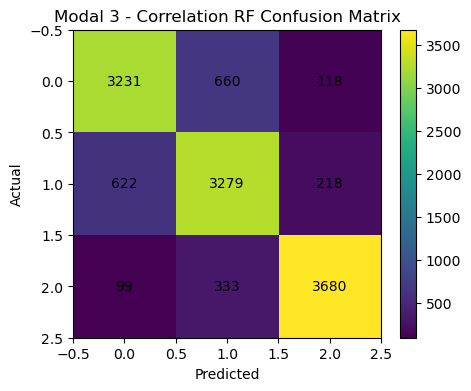

In [15]:
best_model = corr_results.iloc[0]["Model_Object"]
best_cm = corr_results.iloc[0]["Confusion_Matrix"]

m3.plot_confusion_matrix(best_cm, title="Modal 3 - Correlation RF Confusion Matrix")


Feature: UD.five.Shift.r
Real Mean: 0.36198290196078436
VAE Mean: 0.38217331816367645
ChatGPT Mean: 0.3277822807912203
Real Std: 0.2608858552243873
VAE Std: 0.15807019305030595
ChatGPT Std: 0.3057090027694041


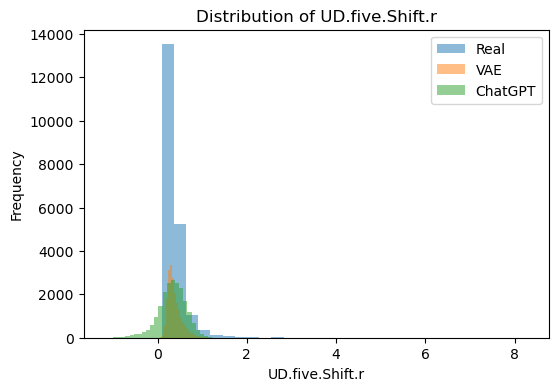

In [16]:
m3.plot_feature_distribution(df, corr_features[0])

In [17]:
m3.validate_best_model(best_model, X_train_corr_scaled, y_train)


3-Fold CV Scores: [0.82340686 0.8213848  0.82267157]
CV Mean: 0.8224877450980391


array([0.82340686, 0.8213848 , 0.82267157])

In [18]:
feature_summary = m3.feature_selection_summary(
    mi_features,
    anova_features,
    corr_features,
    var_features,
    md_features,
    rfe_lr_features,
    rfe_svm_features,
    rfe_rf_features,
    sfm_lr_features,
    sfm_rf_features
)


Feature Selection Summary:
            Feature  Times_Selected
9            UD.i.e               7
13  UD.five.Shift.r               7
11        UD.e.five               6
22           UD.t.i               6
20      UD.period.t               5
17      UD.l.Return               5
15           DD.i.e               5
1          H.Return               5
14     DD.Shift.r.o               5
18     UD.Shift.r.o               5
12              H.a               4
24  DD.five.Shift.r               4
3               H.t               4
16        H.Shift.r               4
21           UD.o.a               3
10        DD.e.five               3
6               H.e               3
4               H.o               3
27           DD.t.i               3
28           DD.o.a               2
19           UD.n.l               2
8               H.n               2
7               H.l               1
23           UD.a.n               1
5               H.i               1
25      DD.l.Return               1


In [19]:
print("BEST METHOD: Correlation + Random Forest")
print("Accuracy:", corr_results.iloc[0]["Accuracy"])

BEST METHOD: Correlation + Random Forest
Accuracy: 0.8325163398692811
